# Proyecto Módulo 7: Segmentador Inteligente de Clientes Minoristas

## Propósito del proyecto

El presente proyecto tiene como finalidad aplicar técnicas de aprendizaje no supervisado para identificar grupos de clientes con características similares dentro de un conjunto de datos minoristas.

## Estructura del desarrollo

- **Lección 1:** Fundamentos del aprendizaje no supervisado
- **Lección 2:** Técnicas de clusterización
- **Lección 3:** Reducción dimensional y preprocesamiento  
- **Lección 4:** Aplicación práctica de clusterización con Python
- **Lección 5:** Evaluación e informe de resultados

# Lección 1: Fundamentos del aprendizaje no supervisado

## Objetivo de la lección
Objetivo: Comprender los fundamentos teóricos del aprendizaje no supervisado y sus diferencias con el aprendizaje supervisado.

## Puntos a desarrollar

1. Identificar las principales tareas que resuelve el aprendizaje no supervisado

- El aprendizaje no supervisado es una rama del aprendizaje automático en la que los datos no se presentan con una variable objetivo que el modelo deba predecir directamente. En lugar de ello, el propósito es descubrir patrones, estructuras o agrupaciones ocultas dentro de los datos.

- En este proyecto, la organización busca segmentar clientes según sus características demográficas, familiares, profesionales y de comportamiento de gasto. Por tanto, no se parte de una predicción directa, sino de la identificación de grupos naturales de clientes.

2. Clasificar técnicas por tipo (clusterización, reducción, asociación) y casos reales de aplicación

- **Clustering:** para agrupar clientes semejantes.
- **Reducción de dimensionalidad:** para representar la información de manera más simple y visualizable.
- **Exploración de patrones ocultos:** para detectar segmentos útiles en marketing y negocio.

Aunque el dataset contiene una columna llamada `Segmentation`, en el desarrollo del proyecto esta variable no será utilizada para entrenar los algoritmos, ya que el enfoque exigido es no supervisado. Solo se podrá usar al final como referencia comparativa.

# Lección 2: Técnicas de clusterización

## Objetivo de la lección
Conocer en profundidad la técnica de clusterización y sus
aplicaciones.

## Puntos a desarrollar
- Definir escenarios donde se aplique clusterización
- Explicar ventajas y desventajas de la técnica
- Comparar K-Means, DBSCAN y agrupamiento jerárquico teóricamente
- Asociar cada algoritmo a un tipo de dato o problema real

## Fundamento teórico de los algoritmos

### K-Means
K-Means es un algoritmo de particionamiento que divide los datos en un número predefinido de grupos, minimizando la distancia entre cada punto y el centroide de su cluster. Es útil cuando se esperan grupos compactos y relativamente bien separados.

### DBSCAN
DBSCAN es un algoritmo basado en densidad. Agrupa puntos que se encuentran en regiones densamente pobladas y marca como ruido aquellos puntos que no pertenecen a zonas densas. Es útil para detectar outliers y grupos de forma irregular.

### Clustering jerárquico
El clustering jerárquico construye una estructura de agrupamiento progresivo, que puede visualizarse mediante un dendrograma. Esto permite analizar relaciones entre subgrupos y niveles de agrupación.

## Justificación de uso en el proyecto

Se emplearán los tres algoritmos para comparar comportamientos diferentes:

- **K-Means** como técnica base de segmentación.
- **DBSCAN** para explorar densidades y posibles outliers.
- **Jerárquico** para observar relaciones estructurales entre clientes.

# Lección 3: Reducción Dimensional y Preprocesamiento

## Objetivo de la lección
Aprender a aplicar técnicas de reducción de dimensionalidad
como PCA y t-SNE.

## Puntos a desarrollar
- Mostrar información del DATASET
- Preparar un dataset de alta dimensión
- Implementar PCA y t-SNE con scikit-learn
- Visualizar y comparar los resultados
- Justificar cuál técnica conviene para el problema actual

# Información del DATASET

In [93]:
##### En esta parte se carga DATASET y se muestra:
# Primeras 5 filas y dimensiones
# Información general
# Conteo de valores nulos
# Estadística descriptiva de datos numéricos y descripcion de datos categóricos

import pandas as pd

# Cargar dataset
df = pd.read_csv("dataset.csv")

print("Dimensiones de DATASET:", df.shape)

# Visualización inicial del dataset
df.head()

Dimensiones de DATASET: (8068, 11)


,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
0,462809,Male,No,22,No,Healthcare,1.0,Low,4.0,Cat_4,D
1,462643,Female,Yes,38,Yes,Engineer,NaN,Average,3.0,Cat_4,A
2,466315,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,Cat_6,B
3,461735,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,Cat_6,B
4,462669,Female,Yes,40,Yes,Entertainment,NaN,High,6.0,Cat_6,A


In [94]:
# Información general del dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8068 entries, 0 to 8067
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               8068 non-null   int64  
 1   Gender           8068 non-null   str    
 2   Ever_Married     7928 non-null   str    
 3   Age              8068 non-null   int64  
 4   Graduated        7990 non-null   str    
 5   Profession       7944 non-null   str    
 6   Work_Experience  7239 non-null   float64
 7   Spending_Score   8068 non-null   str    
 8   Family_Size      7733 non-null   float64
 9   Var_1            7992 non-null   str    
 10  Segmentation     8068 non-null   str    
dtypes: float64(2), int64(2), str(7)
memory usage: 693.5 KB


In [95]:
# Revisión de valores nulos
print("\nConteo de valores nulos:\n")
df.isnull().sum()


Conteo de valores nulos:



ID                   0
Gender               0
Ever_Married       140
Age                  0
Graduated           78
Profession         124
Work_Experience    829
Spending_Score       0
Family_Size        335
Var_1               76
Segmentation         0
dtype: int64

In [96]:
# Mostramos estadísticas descriptivas solo de variables numéricas:
df.describe()

,ID,Age,Work_Experience,Family_Size
count,8068.000000,8068.000000,7239.000000,7733.000000
mean,463479.214551,43.466906,2.641663,2.850123
std,2595.381232,16.711696,3.406763,1.531413
min,458982.000000,18.000000,0.000000,1.000000
25%,461240.750000,30.000000,0.000000,2.000000
50%,463472.500000,40.000000,1.000000,3.000000
75%,465744.250000,53.000000,4.000000,4.000000
max,467974.000000,89.000000,14.000000,9.000000


In [97]:
# Descripción de variables categóricas
df.describe(include="object")

C:\Users\ginom\AppData\Local\Temp\ipykernel_18080\2535796746.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,Gender,Ever_Married,Graduated,Profession,Spending_Score,Var_1,Segmentation
count,8068,7928,7990,7944,8068,7992,8068
unique,2,2,2,9,3,7,4
top,Male,Yes,Yes,Artist,Low,Cat_6,D
freq,4417,4643,4968,2516,4878,5238,2268


# Preparar un dataset de alta dimensión

In [98]:
# En esta parte se preparamos las variables para el análisis.
# Se elimina las siguientes variables:
# - ID: porque es solo un identificador no aporta información útil.
# - Segmentation: porque no debe usarse para entrenar en un enfoque no supervisado
# Se guarda Segmentation aparte solo como referencia final opcional.
# Este data set ya estaba trabajado por eso tiene la columna Segmentation.

X = df.drop(columns=["ID", "Segmentation"])
y_ref = df["Segmentation"]  # referencia externa, no se usa para entrenar

# Se identifica las columnas numéricas y categóricas.
# Esto será útil para aplicar transformaciones distintas a cada tipo de variable.
num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()

print("Variables numéricas:", num_cols)
print("Variables categóricas:", cat_cols)

Variables numéricas: ['Age', 'Work_Experience', 'Family_Size']
Variables categóricas: ['Gender', 'Ever_Married', 'Graduated', 'Profession', 'Spending_Score', 'Var_1']


C:\Users\ginom\AppData\Local\Temp\ipykernel_18080\2033441881.py:14: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=["object"]).columns.tolist()


In [99]:
# Importamos herramientas de preprocesamiento.
# ColumnTransformer: permite aplicar transformaciones diferentes a columnas distintas
# Pipeline: organiza varios pasos en secuencia
# SimpleImputer: rellena valores faltantes
# OneHotEncoder: convierte variables categóricas en variables numéricas binarias
# StandardScaler: estandariza variables numéricas

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Se define el tratamiento para variables numéricas:
# 1. rellenar nulos con la mediana
# 2. escalar para que queden centradas y comparables

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Se define el tratamiento para variables categóricas:
# 1. rellenar nulos con la categoría más frecuente
# 2. codificar con One-Hot Encoding para convertirlas en formato numérico

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Se combina ambos procesos en un solo transformador general.
# Así, cada grupo de columnas recibe el tratamiento correspondiente.
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, num_cols),
    ("cat", categorical_transformer, cat_cols)
])

# Ajustamos el transformador al dataset y transformamos los datos.
# El resultado es una matriz lista para clustering.
X_prep = preprocessor.fit_transform(X)

# Mostramos la nueva dimensión del dataset luego de la transformación.
# Generalmente aumenta el número de columnas por el One-Hot Encoding.
print("Dimensión de la matriz transformada:", X_prep.shape)

# Algunos algoritmos y técnicas trabajan mejor con matrices densas.
# Si el resultado del preprocesamiento está en formato disperso (sparse),
# lo convertimos a formato denso con .toarray().
# Si ya es denso, se conserva tal cual.

X_dense = X_prep.toarray() if hasattr(X_prep, "toarray") else X_prep


Dimensión de la matriz transformada: (8068, 28)


# PCA

C:\Users\ginom\AppData\Local\Temp\ipykernel_18080\1677471942.py:22: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.5, cmap="viridis")


Varianza explicada por componente: [0.25384139 0.17437737]
Varianza acumulada: 0.42821876070540543


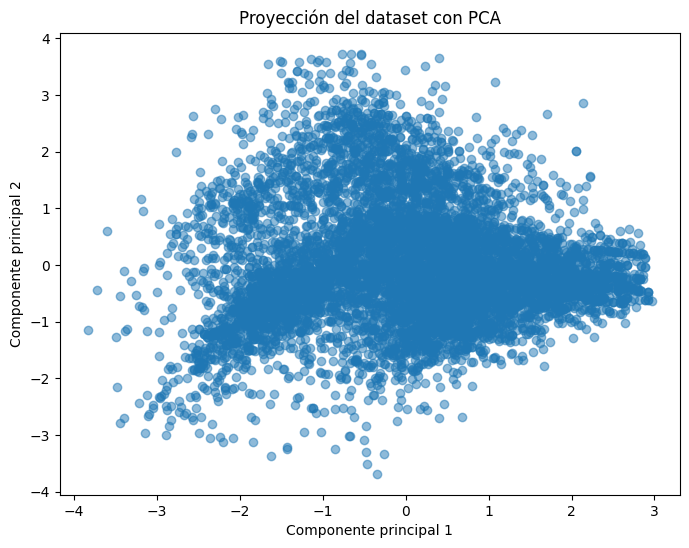

In [100]:
# Importar PCA, técnica de reducción dimensional lineal.
# Su objetivo es resumir la información del dataset en menos dimensiones.
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Creamos un PCA de 2 componentes para poder visualizar los datos en un plano.
pca = PCA(n_components=2, random_state=42)

# Ajustamos PCA a los datos transformados y obtenemos la proyección en 2 dimensiones.
X_pca = pca.fit_transform(X_dense)

# Mostramos cuánta varianza explica cada componente y la varianza acumulada.
# Esto ayuda a entender cuánta información conservan estas dos dimensiones.
print("Varianza explicada por componente:", pca.explained_variance_ratio_)
print("Varianza acumulada:", pca.explained_variance_ratio_.sum())

# Gráficas de PCA.
# Cada punto representa un cliente en el espacio de dos componentes principales.
# Esta visualización ayuda a detectar si existen agrupamientos generales.

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.5, cmap="viridis")
plt.title("Proyección del dataset con PCA")
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.show()

# t-SNE


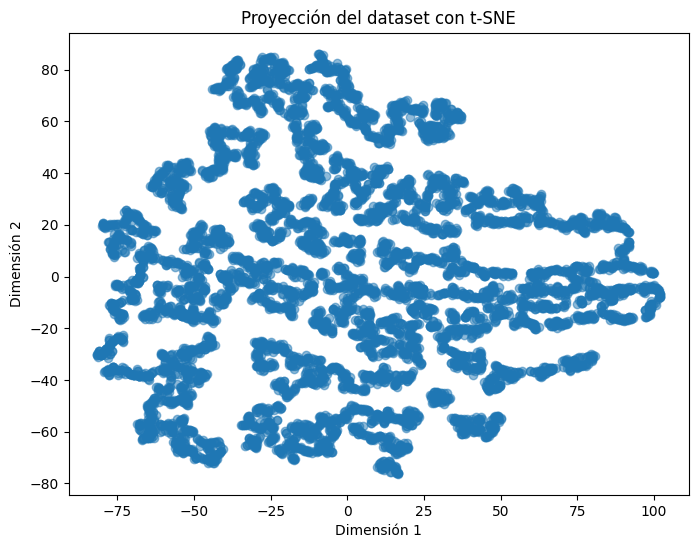

In [101]:
# Importamos t-SNE, una técnica no lineal de reducción dimensional
# muy útil para visualizar estructuras locales y posibles clusters.

from sklearn.manifold import TSNE

# Configuramos t-SNE para obtener una representación en 2 dimensiones.
# Se usa init="pca" para iniciar desde una estructura razonable.
tsne = TSNE(n_components=2, perplexity=30, learning_rate="auto", init="pca", random_state=42)

# Aplicamos t-SNE sobre la representación PCA.
# Esto reduce costo computacional y suele mejorar estabilidad visual.
X_tsne = tsne.fit_transform(X_pca)

# Graficamos la proyección obtenida con t-SNE.
# Esta representación puede mostrar mejor separaciones locales
# entre grupos de clientes.

plt.figure(figsize=(8,6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], alpha=0.5)
plt.title("Proyección del dataset con t-SNE")
plt.xlabel("Dimensión 1")
plt.ylabel("Dimensión 2")
plt.show()

## Comparación entre PCA y t-SNE

En esta sección se comparan ambas técnicas desde el punto de vista visual para evaluar cuál permite observar mejor la estructura de los datos.

Es importante destacar que:

- PCA se utiliza como técnica base para reducción dimensional.
- t-SNE se utiliza principalmente para visualización.

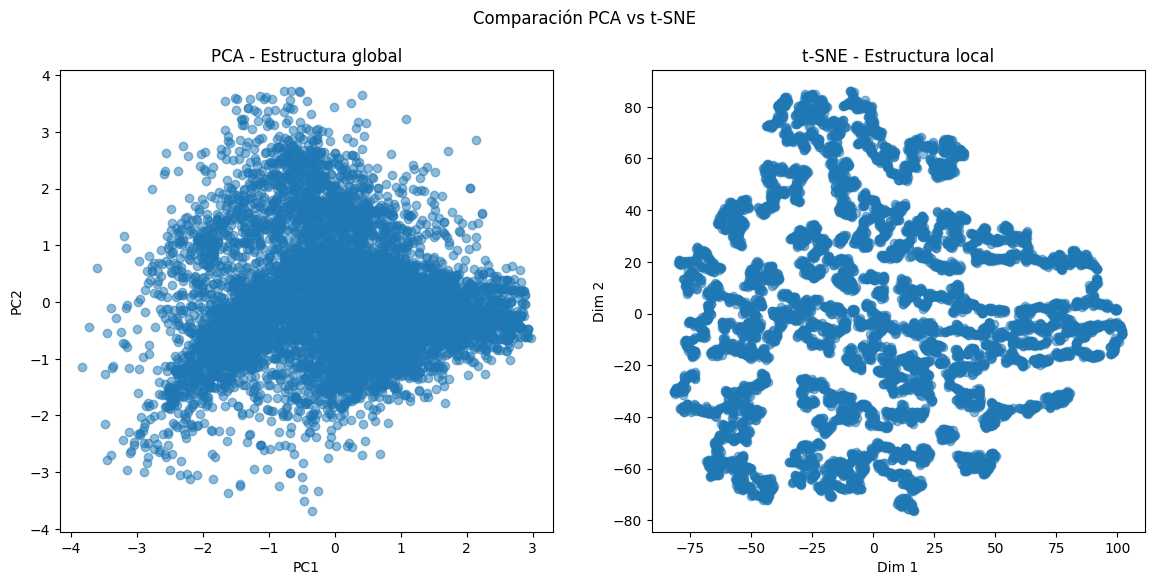

In [102]:
# Comparación visual entre PCA y t-SNE

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# PCA
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.5)
axes[0].set_title("PCA - Estructura global")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")

# t-SNE
axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], alpha=0.5)
axes[1].set_title("t-SNE - Estructura local")
axes[1].set_xlabel("Dim 1")
axes[1].set_ylabel("Dim 2")

plt.suptitle("Comparación PCA vs t-SNE")
plt.show()

# Lección 4: Aplicación práctica de Clusterización con Python

## Objetivo de la lección
Implementar un pipeline de clusterización aplicando K-Means,
DBSCAN y agrupamiento jerárquico.

## Puntos a desarrollar

1. Seleccionar un valor de k para K-Means.
2. Aplicar K-Means.
3. Aplicar DBSCAN.
4. Aplicar clustering jerárquico.
5. Visualizar clusters.
6. Generar un dendrograma.

## Observación metodológica

En el caso de K-Means, el número de clusters se justificará mediante:
- método del codo
- silhouette score

In [103]:
# Importamos algoritmos de clustering y herramientas auxiliares.
# KMeans: clustering por centroides
# DBSCAN: clustering por densidad
# AgglomerativeClustering: clustering jerárquico
# silhouette_score: métrica para evaluar calidad de agrupamiento
# NearestNeighbors: útil para estimar eps en DBSCAN
# linkage y dendrogram: para construir y visualizar dendrogramas

from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import linkage, dendrogram
import seaborn as sns

# K-Means


Codo

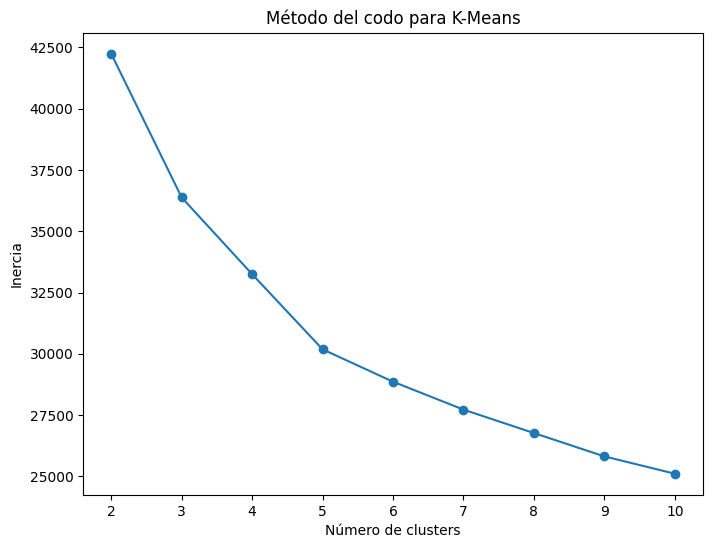

In [104]:
# Método del codo para K-Means.
# Probamos distintos valores de k (cantidad de clusters)
# y calculamos la inercia en cada caso.
# La inercia mide qué tan cerca están los puntos de su centroide.

inertias = []
k_values = range(2, 11)

for k in k_values:
    # Creamos el modelo con k clusters
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    
    # Ajustamos el modelo a los datos preprocesados
    km.fit(X_prep)
    
    # Guardamos la inercia obtenida
    inertias.append(km.inertia_)

# Graficamos la inercia para identificar visualmente el "codo",
# es decir, el punto a partir del cual aumentar k aporta menos mejora.
plt.figure(figsize=(8,6))
plt.plot(k_values, inertias, marker="o")
plt.title("Método del codo para K-Means")
plt.xlabel("Número de clusters")
plt.ylabel("Inercia")
plt.show()

Silhouette

k = 2 -> silhouette = 0.1724
k = 3 -> silhouette = 0.1941
k = 4 -> silhouette = 0.1484
k = 5 -> silhouette = 0.1633
k = 6 -> silhouette = 0.1581
k = 7 -> silhouette = 0.1507
k = 8 -> silhouette = 0.1484
k = 9 -> silhouette = 0.1390
k = 10 -> silhouette = 0.1363


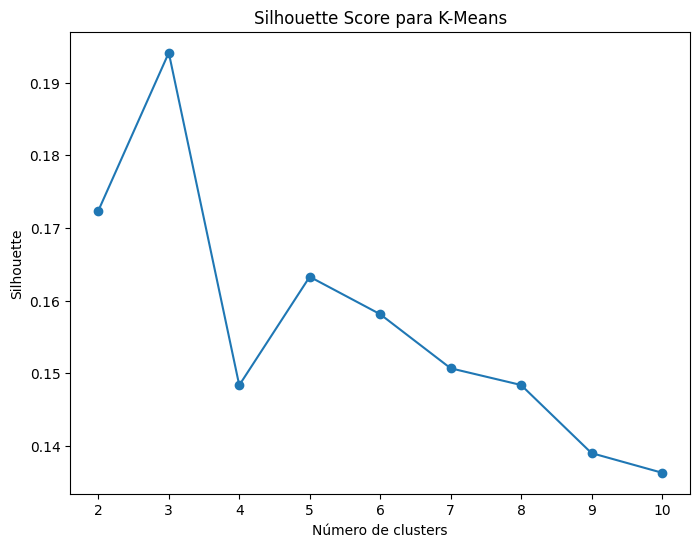

In [105]:
# Calculamos el silhouette score para distintos valores de k.
# Esta métrica evalúa qué tan bien separados y compactos están los clusters.
# Valores más altos suelen indicar mejor segmentación.

sil_scores = []

for k in range(2, 11):
    # Creamos el modelo K-Means
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    
    # Obtenemos las etiquetas de cluster para cada observación
    labels = km.fit_predict(X_prep)
    
    # Calculamos la métrica silhouette
    score = silhouette_score(X_prep, labels)
    sil_scores.append(score)
    
    # Mostramos el resultado para cada valor de k
    print(f"k = {k} -> silhouette = {score:.4f}")

# Graficamos la evolución del silhouette score.
plt.figure(figsize=(8,6))
plt.plot(range(2, 11), sil_scores, marker="o")
plt.title("Silhouette Score para K-Means")
plt.xlabel("Número de clusters")
plt.ylabel("Silhouette")
plt.show()

## Selección de k

A partir de los resultados anteriores, se debe elegir el valor de `k` que presente un equilibrio razonable entre interpretación visual del método del codo y calidad del silhouette score.

En este desarrollo se utilizará inicialmente `k = 4`, ya que además coincide con la cantidad de categorías presentes en la columna `Segmentation`, aunque esa variable no se use para entrenar.

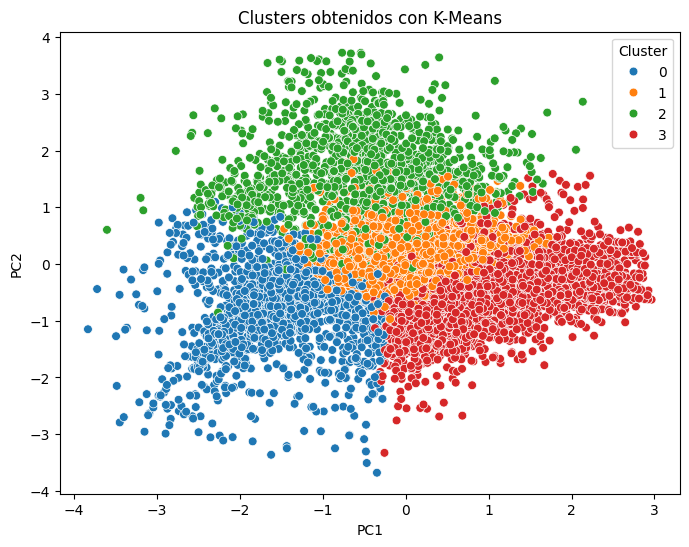

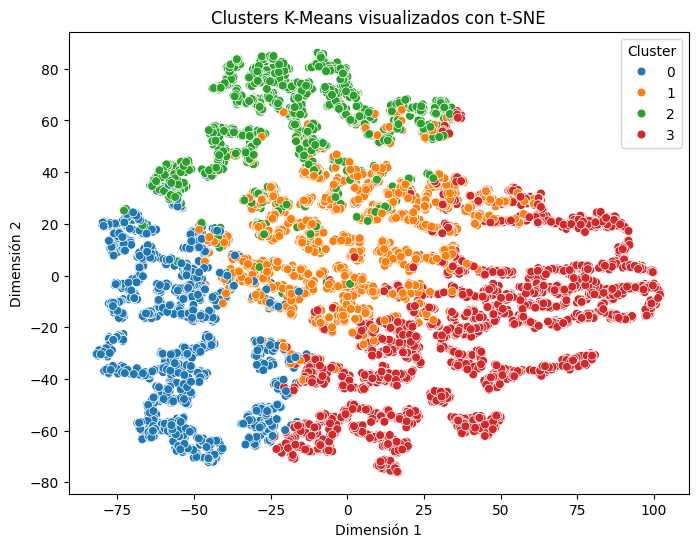

In [106]:
# Entrenamiento final de K-Means

k_final = 4
kmeans = KMeans(n_clusters=k_final, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_prep)

# Visualización de K-Means en espacio PCA

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=kmeans_labels, palette="tab10", s=40)
plt.title("Clusters obtenidos con K-Means")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Cluster")
plt.show()

# Visualización de K-Means en espacio t-SNE

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=kmeans_labels, palette="tab10", s=40)
plt.title("Clusters K-Means visualizados con t-SNE")
plt.xlabel("Dimensión 1")
plt.ylabel("Dimensión 2")
plt.legend(title="Cluster")
plt.show()

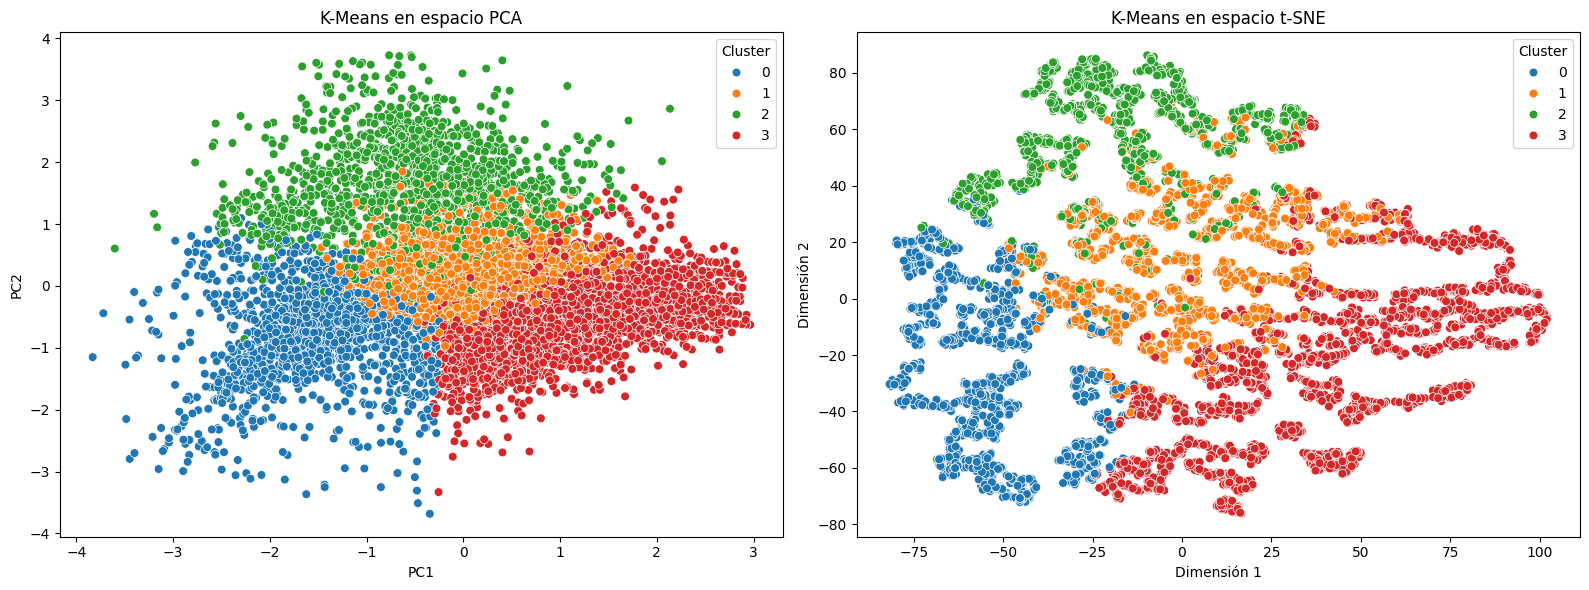

In [107]:
# Comparación: Visualización de clusters K-Means en PCA vs t-SNE

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- PCA ---
sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=kmeans_labels,
    palette="tab10",
    s=40,
    ax=axes[0]
)
axes[0].set_title("K-Means en espacio PCA")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].legend(title="Cluster")

# --- t-SNE ---
sns.scatterplot(
    x=X_tsne[:, 0],
    y=X_tsne[:, 1],
    hue=kmeans_labels,
    palette="tab10",
    s=40,
    ax=axes[1]
)
axes[1].set_title("K-Means en espacio t-SNE")
axes[1].set_xlabel("Dimensión 1")
axes[1].set_ylabel("Dimensión 2")
axes[1].legend(title="Cluster")

plt.tight_layout()
plt.show()

# DBSCAN

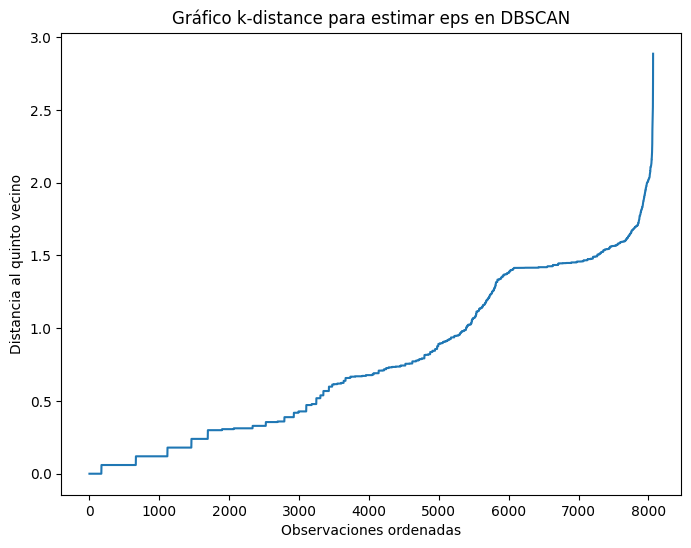

In [140]:
import numpy as np

# Búsqueda orientativa de eps para DBSCAN usando gráfico de distancias

neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_prep)
distances, indices = neighbors_fit.kneighbors(X_prep)

distances = np.sort(distances[:, 4])

plt.figure(figsize=(8,6))
plt.plot(distances)
plt.title("Gráfico k-distance para estimar eps en DBSCAN")
plt.xlabel("Observaciones ordenadas")
plt.ylabel("Distancia al quinto vecino")
plt.show()

In [158]:
# Aplicación de DBSCAN
# El valor de eps puede ajustarse visualmente según el gráfico anterior

dbscan = DBSCAN(eps=1.7, min_samples=3)
dbscan_labels = dbscan.fit_predict(X_prep)

print("Etiquetas únicas de DBSCAN:", np.unique(dbscan_labels))
print("Cantidad de clusters detectados:", len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0))
print("Cantidad de puntos ruido:", np.sum(dbscan_labels == -1))

Etiquetas únicas de DBSCAN: [-1  0  1]
Cantidad de clusters detectados: 2
Cantidad de puntos ruido: 57


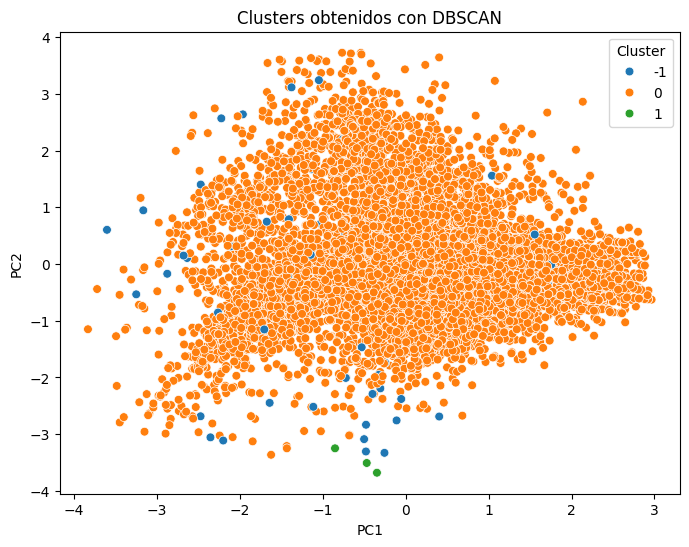

In [159]:
# Visualización de DBSCAN en espacio PCA

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=dbscan_labels, palette="tab10", s=40)
plt.title("Clusters obtenidos con DBSCAN")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Cluster")
plt.show()

# Búsqueda de parámetros para DBSCAN

In [150]:
# ============================================================
# BÚSQUEDA DE PARÁMETROS PARA DBSCAN
# ============================================================

# Esta celda prueba múltiples combinaciones de parámetros
# (eps y min_samples) para DBSCAN y evalúa:
# - número de clusters encontrados
# - cantidad de ruido
# - silhouette score (si es posible calcularlo)

results = []

# Definimos rangos de parámetros a probar
eps_values = np.arange(0.5, 3.0, 0.3)      # puedes ajustar este rango
min_samples_values = [3, 5, 10]

for eps in eps_values:
    for min_samples in min_samples_values:
        
        # Entrenamos DBSCAN con la combinación actual
        db = DBSCAN(eps=eps, min_samples=min_samples)
        labels = db.fit_predict(X_prep)
        
        # Calculamos número de clusters (excluyendo ruido -1)
        unique_labels = set(labels)
        n_clusters = len(unique_labels - {-1})
        
        # Contamos ruido
        noise_points = np.sum(labels == -1)
        
        # Evaluamos silhouette solo si hay al menos 2 clusters válidos
        valid = labels != -1
        if n_clusters > 1:
            sil = silhouette_score(X_prep[valid], labels[valid])
        else:
            sil = np.nan
        
        # Guardamos resultados
        results.append({
            "eps": eps,
            "min_samples": min_samples,
            "clusters": n_clusters,
            "noise_points": noise_points,
            "silhouette": sil
        })

# Convertimos a DataFrame
results_df = pd.DataFrame(results)

# Ordenamos por silhouette (mejores arriba)
results_df_sorted = results_df.sort_values(by="silhouette", ascending=False)

results_df_sorted.head(10)

,eps,min_samples,clusters,noise_points,silhouette
2,0.5,10,79,5579,0.431715
0,0.5,3,440,3540,0.368943
1,0.5,5,204,4449,0.357197
12,1.7,3,2,57,0.352055
5,0.8,10,79,3724,0.268352
8,1.1,10,101,2945,0.222200
4,0.8,5,167,2685,0.217816
11,1.4,10,109,2440,0.202182
3,0.8,3,303,1996,0.198086
7,1.1,5,189,2053,0.183997


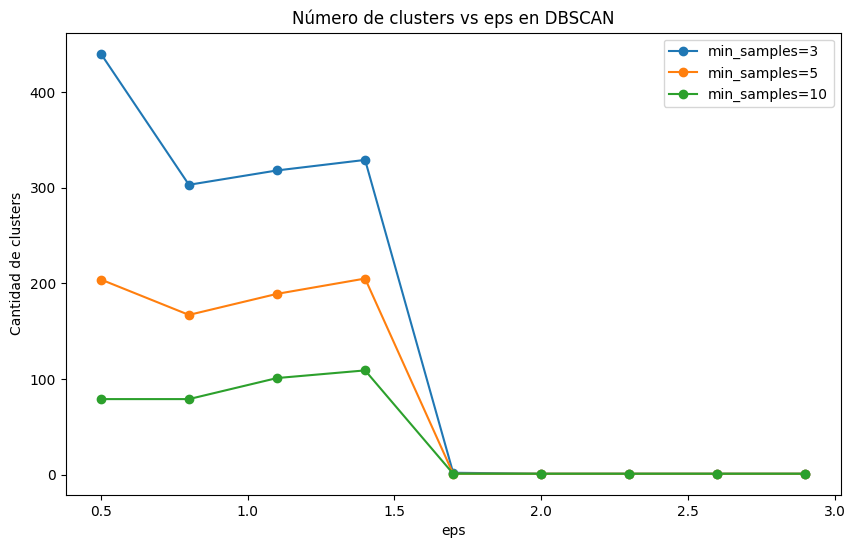

In [151]:
# Visualizamos cómo cambia el número de clusters según eps

plt.figure(figsize=(10,6))

for ms in results_df["min_samples"].unique():
    subset = results_df[results_df["min_samples"] == ms]
    plt.plot(subset["eps"], subset["clusters"], marker="o", label=f"min_samples={ms}")

plt.title("Número de clusters vs eps en DBSCAN")
plt.xlabel("eps")
plt.ylabel("Cantidad de clusters")
plt.legend()
plt.show()

In [160]:
# Seleccionamos la mejor combinación automáticamente

best_row = results_df_sorted.iloc[0]

print("Mejor configuración encontrada:")
print(best_row)

# Entrenamos DBSCAN con los mejores parámetros

best_dbscan = DBSCAN(
    eps=best_row["eps"],
    min_samples=int(best_row["min_samples"])
)

best_dbscan_labels = best_dbscan.fit_predict(X_prep)

Mejor configuración encontrada:
eps                0.500000
min_samples       10.000000
clusters          79.000000
noise_points    5579.000000
silhouette         0.431715
Name: 2, dtype: float64


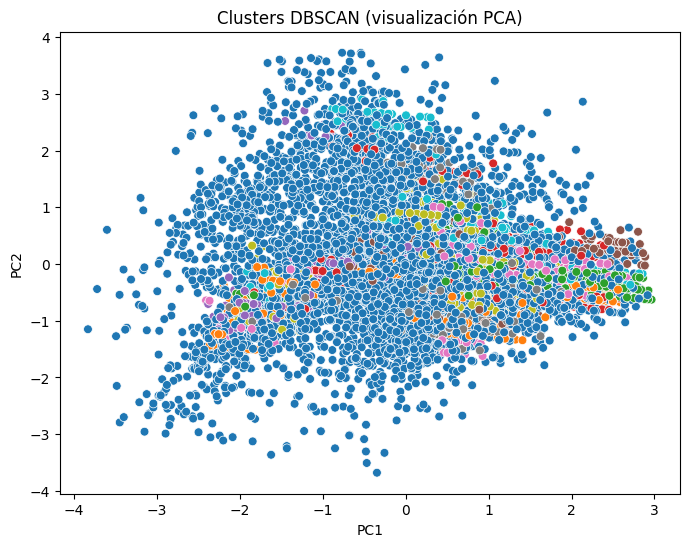

In [ ]:
# ============================================================
# GRÁFICO CONFIGURACIÓN AUTOMATICA
# ============================================================

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=best_dbscan_labels,
    palette="tab10",
    s=40,
    legend=False  # 👈 quitamos la leyenda del gráfico
)

plt.title("Clusters DBSCAN (visualización PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.show()


# Cluster Jerárquico

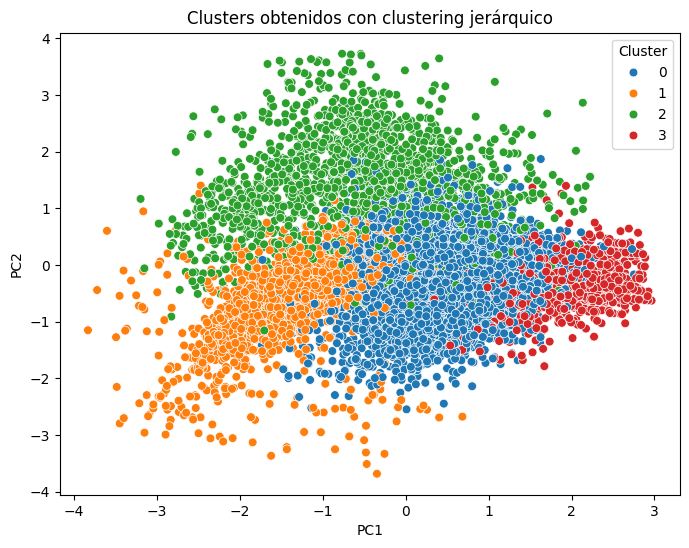

In [117]:
# Aplicamos clustering jerárquico aglomerativo.
# Usamos linkage="ward", que intenta minimizar la varianza interna
# de los grupos al ir fusionando observaciones o subgrupos.

agg = AgglomerativeClustering(n_clusters=4, linkage="ward")

# Obtenemos la etiqueta de cluster de cada observación
agg_labels = agg.fit_predict(X_dense)

# Visualizamos los clusters jerárquicos en el espacio PCA.
# Esto permite comparar visualmente este método con K-Means y DBSCAN.

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=agg_labels, palette="tab10", s=40)
plt.title("Clusters obtenidos con clustering jerárquico")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Cluster")
plt.show()

Dendograma

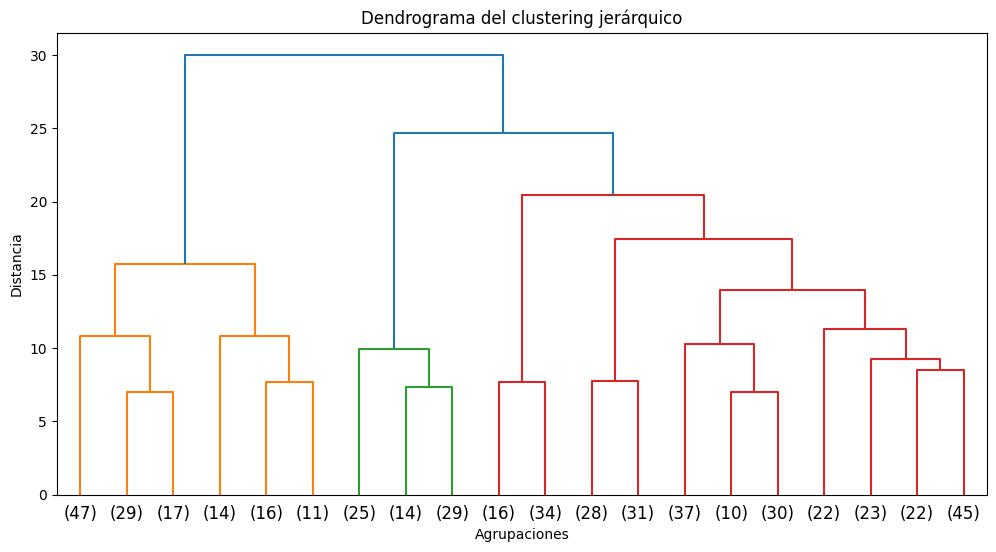

In [112]:
# Para construir un dendrograma de forma eficiente,
# tomamos una muestra del dataset en lugar de usar todas las observaciones.
# Esto reduce el costo computacional y mejora la legibilidad del gráfico.

sample_size = 500
np.random.seed(42)

# Seleccionamos índices aleatorios sin reemplazo
sample_idx = np.random.choice(range(X_dense.shape[0]), size=sample_size, replace=False)

# Extraemos la muestra
X_sample = X_dense[sample_idx]

# Construimos la matriz de enlace jerárquico usando el método Ward
linked = linkage(X_sample, method="ward")

# Dibujamos el dendrograma truncado para visualizar los grupos más relevantes
plt.figure(figsize=(12,6))
dendrogram(linked, truncate_mode="lastp", p=20)
plt.title("Dendrograma del clustering jerárquico")
plt.xlabel("Agrupaciones")
plt.ylabel("Distancia")
plt.show()

# Lección 5: Evaluación e Informe de Resultados

## Objetivo
Sintetizar los hallazgos y generar un reporte con
recomendaciones accionables.

## Puntos a desarrollar
- Comparar las segmentaciones generadas
- Evaluar la consistencia de los resultados
- Elaborar un informe con visualizaciones
- Sugerir usos comerciales para los segmentos

In [161]:
# Comparamos cuantitativamente los modelos usando silhouette score.
# Esto permite evaluar cuál de los métodos produce clusters más compactos
# y mejor separados.

results = []

# Evaluación de K-Means
km_sil = silhouette_score(X_prep, kmeans_labels)
results.append(("K-Means", km_sil))

# Evaluación de DBSCAN
# Excluimos los puntos etiquetados como ruido (-1),
# ya que no pertenecen a clusters válidos.
valid_db = dbscan_labels != -1

# Solo calculamos silhouette si hay al menos dos clusters válidos.
if len(set(dbscan_labels[valid_db])) > 1:
    db_sil = silhouette_score(X_prep[valid_db], dbscan_labels[valid_db])
else:
    db_sil = np.nan

results.append(("DBSCAN", db_sil))

# Evaluación de clustering jerárquico
agg_sil = silhouette_score(X_dense, agg_labels)
results.append(("Jerárquico", agg_sil))

# Convertimos los resultados en una tabla para comparar fácilmente.
results_df = pd.DataFrame(results, columns=["Modelo", "Silhouette Score"])
results_df

,Modelo,Silhouette Score
0,K-Means,0.148362
1,DBSCAN,0.352055
2,Jerárquico,0.136267


In [162]:
# ============================================================
# COMPARACIÓN FINAL DE MODELOS
# Incluye:
# - K-Means
# - Clustering jerárquico
# - DBSCAN con búsqueda automática de parámetros
# ============================================================

from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score

# -------------------------------
# 1. K-MEANS
# -------------------------------
kmeans_final = KMeans(n_clusters=k_final, random_state=42, n_init=10)
kmeans_labels_final = kmeans_final.fit_predict(X_prep)

kmeans_n_clusters = len(np.unique(kmeans_labels_final))
kmeans_noise = 0
kmeans_silhouette = silhouette_score(X_prep, kmeans_labels_final)

# -------------------------------
# 2. CLUSTERING JERÁRQUICO
# -------------------------------
agg_final = AgglomerativeClustering(n_clusters=4, linkage="ward")
agg_labels_final = agg_final.fit_predict(X_dense)

agg_n_clusters = len(np.unique(agg_labels_final))
agg_noise = 0
agg_silhouette = silhouette_score(X_dense, agg_labels_final)

# -------------------------------
# 3. DBSCAN CON BÚSQUEDA AUTOMÁTICA
# -------------------------------
dbscan_results = []

# Rango de parámetros a explorar
eps_values = np.arange(0.5, 3.0, 0.3)
min_samples_values = [3, 5, 10]

for eps in eps_values:
    for min_samples in min_samples_values:
        db = DBSCAN(eps=eps, min_samples=min_samples)
        labels = db.fit_predict(X_prep)

        unique_labels = set(labels)
        n_clusters = len(unique_labels - {-1})
        noise_points = np.sum(labels == -1)

        valid = labels != -1

        # Silhouette solo si hay al menos 2 clusters válidos
        if n_clusters > 1:
            sil = silhouette_score(X_prep[valid], labels[valid])
        else:
            sil = np.nan

        dbscan_results.append({
            "eps": eps,
            "min_samples": min_samples,
            "clusters": n_clusters,
            "noise_points": noise_points,
            "silhouette": sil
        })

dbscan_results_df = pd.DataFrame(dbscan_results)

# Filtramos solo resultados válidos con silhouette calculable
dbscan_valid = dbscan_results_df.dropna(subset=["silhouette"]).copy()

if not dbscan_valid.empty:
    # Elegimos la mejor combinación según silhouette más alto
    best_dbscan_row = dbscan_valid.sort_values(by="silhouette", ascending=False).iloc[0]

    best_eps = best_dbscan_row["eps"]
    best_min_samples = int(best_dbscan_row["min_samples"])

    dbscan_final = DBSCAN(eps=best_eps, min_samples=best_min_samples)
    dbscan_labels_final = dbscan_final.fit_predict(X_prep)

    dbscan_n_clusters = len(set(dbscan_labels_final) - {-1})
    dbscan_noise = np.sum(dbscan_labels_final == -1)

    valid_final = dbscan_labels_final != -1
    dbscan_silhouette = silhouette_score(X_prep[valid_final], dbscan_labels_final[valid_final])

    dbscan_params = f"eps={best_eps}, min_samples={best_min_samples}"
else:
    # Si no se encontró ninguna combinación válida
    dbscan_labels_final = None
    dbscan_n_clusters = 0
    dbscan_noise = np.nan
    dbscan_silhouette = np.nan
    dbscan_params = "No se encontraron parámetros válidos"

# -------------------------------
# 4. TABLA COMPARATIVA FINAL
# -------------------------------
comparison_models = pd.DataFrame([
    {
        "Modelo": "K-Means",
        "Parámetros": f"k={k_final}",
        "N° clusters": kmeans_n_clusters,
        "Ruido": kmeans_noise,
        "Silhouette Score": kmeans_silhouette
    },
    {
        "Modelo": "Jerárquico",
        "Parámetros": "n_clusters=4, linkage=ward",
        "N° clusters": agg_n_clusters,
        "Ruido": agg_noise,
        "Silhouette Score": agg_silhouette
    },
    {
        "Modelo": "DBSCAN",
        "Parámetros": dbscan_params,
        "N° clusters": dbscan_n_clusters,
        "Ruido": dbscan_noise,
        "Silhouette Score": dbscan_silhouette
    }
])

comparison_models.sort_values(by="Silhouette Score", ascending=False)

,Modelo,Parámetros,N° clusters,Ruido,Silhouette Score
2,DBSCAN,"eps=0.5, min_samples=10",79,5579,0.431715
0,K-Means,k=4,4,0,0.148362
1,Jerárquico,"n_clusters=4, linkage=ward",4,0,0.136267


In [163]:
# Creamos una copia del dataset original e incorporamos las etiquetas
# generadas por cada algoritmo de clustering.
# Esto permite analizar e interpretar los grupos en términos
# de las variables originales.

df_clusters = df.copy()
df_clusters["Cluster_KMeans"] = kmeans_labels
df_clusters["Cluster_Jerarquico"] = agg_labels
df_clusters["Cluster_DBSCAN"] = dbscan_labels

df_clusters.head()

,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation,Cluster_KMeans,Cluster_Jerarquico,Cluster_DBSCAN
0,462809,Male,No,22,No,Healthcare,1.0,Low,4.0,Cat_4,D,0,1,0
1,462643,Female,Yes,38,Yes,Engineer,NaN,Average,3.0,Cat_4,A,3,0,0
2,466315,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,Cat_6,B,3,0,0
3,461735,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,Cat_6,B,3,3,0
4,462669,Female,Yes,40,Yes,Entertainment,NaN,High,6.0,Cat_6,A,0,0,0


In [164]:
# Calculamos un perfil numérico promedio por cluster K-Means.
# Esto ayuda a describir cada grupo según edad, experiencia laboral
# y tamaño familiar.

cluster_profile_num = df_clusters.groupby("Cluster_KMeans").agg({
    "Age": "mean",
    "Work_Experience": "mean",
    "Family_Size": "mean"
})

cluster_profile_num

,Age,Work_Experience,Family_Size
Cluster_KMeans,,,
0,27.370645,1.455497,4.522809
1,38.495192,1.030172,1.719114
2,37.858478,8.473965,2.449509
3,59.039701,0.977984,2.788787


In [165]:
# Analizamos cómo se distribuye Spending_Score dentro de cada cluster.
# normalize="index" convierte los conteos en proporciones por fila,
# lo que facilita comparar composición relativa entre clusters.

pd.crosstab(df_clusters["Cluster_KMeans"], df_clusters["Spending_Score"], normalize="index")

Spending_Score,Average,High,Low
Cluster_KMeans,,,
0,0.061679,0.047401,0.890919
1,0.106303,0.027244,0.866453
2,0.240320,0.110147,0.649533
3,0.443502,0.311164,0.245334


In [166]:
# Analizamos la distribución de Profession dentro de cada cluster.
# Esto ayuda a identificar si ciertos perfiles ocupacionales
# predominan en grupos específicos.

pd.crosstab(df_clusters["Cluster_KMeans"], df_clusters["Profession"], normalize="index")

Profession,Artist,Doctor,Engineer,Entertainment,Executive,Healthcare,Homemaker,Lawyer,Marketing
Cluster_KMeans,,,,,,,,,
0,0.062392,0.110341,0.087811,0.083767,0.047371,0.526863,0.013865,0.002889,0.064702
1,0.414340,0.117679,0.112206,0.152709,0.016968,0.102901,0.028462,0.010400,0.044335
2,0.348680,0.088693,0.093433,0.132024,0.062288,0.134056,0.091401,0.014218,0.035206
3,0.390512,0.051908,0.070127,0.113441,0.135442,0.011688,0.012032,0.198694,0.016157


In [167]:
# Analizamos la distribución de Ever_Married por cluster.
# Esto permite observar si algunos segmentos concentran más clientes
# casados o no casados.

pd.crosstab(df_clusters["Cluster_KMeans"], df_clusters["Ever_Married"], normalize="index")

Ever_Married,No,Yes
Cluster_KMeans,,
0,0.844005,0.155995
1,0.598481,0.401519
2,0.468707,0.531293
3,0.014843,0.985157


In [168]:
# Analizamos la distribución de Graduated por cluster.
# Esto ayuda a interpretar diferencias educacionales
# entre los grupos encontrados.

pd.crosstab(df_clusters["Cluster_KMeans"], df_clusters["Graduated"], normalize="index")

Graduated,No,Yes
Cluster_KMeans,,
0,0.790805,0.209195
1,0.217672,0.782328
2,0.306026,0.693974
3,0.270826,0.729174


In [169]:
# Comparamos de forma exploratoria los clusters hallados por K-Means
# con la columna original Segmentation.
# Esta comparación no se usa para entrenar, solo para observar
# si existe coherencia entre la segmentación descubierta
# y la segmentación ya presente en el dataset.

comparison_table = pd.crosstab(df_clusters["Cluster_KMeans"], df_clusters["Segmentation"], normalize="index")
comparison_table

Segmentation,A,B,C,D
Cluster_KMeans,,,,
0,0.145631,0.105654,0.130211,0.618504
1,0.363248,0.240385,0.154380,0.241987
2,0.290387,0.206943,0.204272,0.298398
3,0.204276,0.309807,0.389209,0.096709


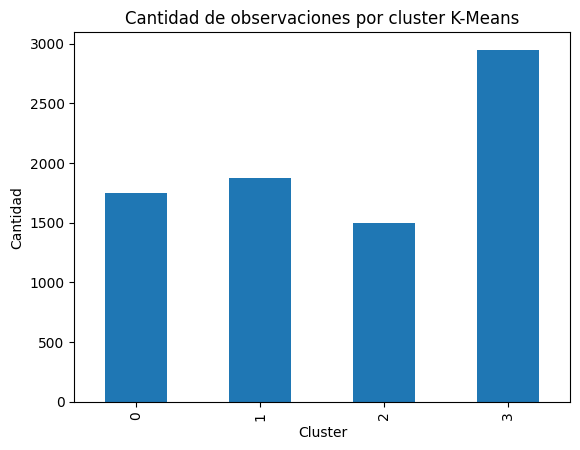

In [128]:
# Graficamos cuántas observaciones contiene cada cluster de K-Means.
# Esto permite ver si los grupos quedaron equilibrados o no.

df_clusters["Cluster_KMeans"].value_counts().sort_index().plot(kind="bar")
plt.title("Cantidad de observaciones por cluster K-Means")
plt.xlabel("Cluster")
plt.ylabel("Cantidad")
plt.show()

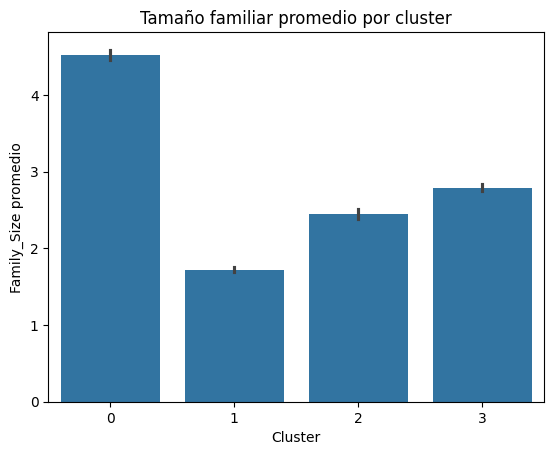

In [170]:
# Graficamos el tamaño familiar promedio por cluster.
# Esto puede revelar segmentos orientados a hogares pequeños o grandes.

sns.barplot(data=df_clusters, x="Cluster_KMeans", y="Family_Size", estimator=np.mean)
plt.title("Tamaño familiar promedio por cluster")
plt.xlabel("Cluster")
plt.ylabel("Family_Size promedio")
plt.show()

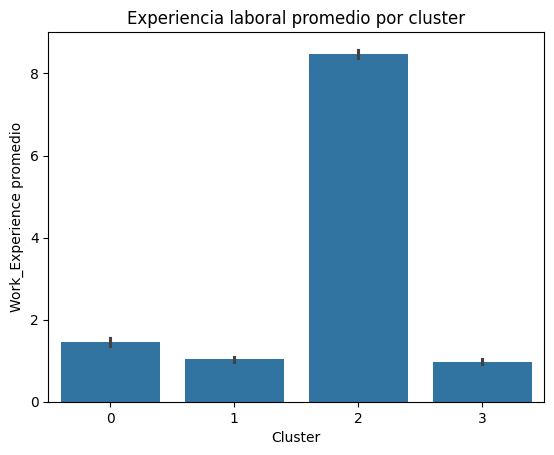

In [171]:
# Graficamos la experiencia laboral promedio por cluster.
# Esto ayuda a diferenciar grupos con mayor o menor trayectoria laboral.

sns.barplot(data=df_clusters, x="Cluster_KMeans", y="Work_Experience", estimator=np.mean)
plt.title("Experiencia laboral promedio por cluster")
plt.xlabel("Cluster")
plt.ylabel("Work_Experience promedio")
plt.show()

In [172]:
# Exportamos el dataset final con las columnas de clusters agregadas.
# Este archivo puede utilizarse como entregable o para análisis posteriores.

df_clusters.to_csv("dataset_segmentado.csv", index=False)
print("Archivo exportado: dataset_segmentado.csv")

Archivo exportado: dataset_segmentado.csv
